# Seasonal analysis review

This notebook loads one AOI preprocessing output and the matching seasonal output, then visualizes the smoothed NDVI curve together with the detected season windows.


In [9]:
from pathlib import Path
import sys
import csv
import json
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "farmtrust_core").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from farmtrust_core.seasonal.seasons import ACTIVITY_THRESHOLD, build_season_payload, load_preprocess_observations

AOI_ID = "aoi_demo_01"
RUN_TAG = "_rerun"

# Prefer rerun outputs when available; fall back to canonical paths.
preprocess_candidate = REPO_ROOT / "data" / "preprocess" / f"{AOI_ID}{RUN_TAG}"
seasonal_candidate = REPO_ROOT / "data" / "seasonal" / f"{AOI_ID}{RUN_TAG}"
PREPROCESS_DIR = preprocess_candidate if preprocess_candidate.exists() else REPO_ROOT / "data" / "preprocess" / AOI_ID
SEASONAL_DIR = seasonal_candidate if seasonal_candidate.exists() else REPO_ROOT / "data" / "seasonal" / AOI_ID

SMOOTHED_CSV_PATH = PREPROCESS_DIR / "ndvi_smoothed.csv"
QUALITY_JSON_PATH = PREPROCESS_DIR / "quality_metrics.json"

assert SMOOTHED_CSV_PATH.exists(), f"Missing {SMOOTHED_CSV_PATH}"
assert QUALITY_JSON_PATH.exists(), f"Missing {QUALITY_JSON_PATH}"


In [10]:
with SMOOTHED_CSV_PATH.open("r", encoding="utf-8", newline="") as handle:
    rows = list(csv.DictReader(handle))

usable_rows = []
for row in rows:
    if row["is_usable"].strip().lower() != "true":
        continue
    if not row["ndvi_smoothed"].strip():
        continue
    usable_rows.append(
        {
            "timestamp": datetime.fromisoformat(row["timestamp"]),
            "ndvi_smoothed": float(row["ndvi_smoothed"]),
            "ndvi_raw": float(row["ndvi_raw"]),
        }
    )

seasonal_observations = load_preprocess_observations(SMOOTHED_CSV_PATH)
activity_threshold = ACTIVITY_THRESHOLD

season_payload = build_season_payload(
    smoothed_csv_path=SMOOTHED_CSV_PATH,
    quality_metrics_path=QUALITY_JSON_PATH,
)
season_payload


{'aoi_id': 'aoi_demo_01',
 'season_count': 4,
 'gap_risk': 'high',
 'seasons': [{'season_id': 'season_01',
   'crossing_date': '2024-06-04',
   'start_date': '2024-05-17',
   'peak_date': '2024-07-11',
   'end_date': '2024-08-25',
   'is_open': False,
   'peak_ndvi': 0.429375,
   'duration_days': 100.0,
   'quality_label': 'good',
   'evidence_summary': 'Good season: peak_ndvi=0.429, rise_gain=0.273.',
   'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.'},
  {'season_id': 'season_02',
   'crossing_date': '2024-10-07',
   'start_date': '2024-09-12',
   'peak_date': '2025-01-12',
   'end_date': '2025-05-22',
   'is_open': False,
   'peak_ndvi': 0.46543,
   'duration_days': 251.99,
   'quality_label': 'good',
   'evidence_summary': 'Good season: peak_ndvi=0.465, rise_gain=0.327.',
   'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.'},
  {'season_id'

In [11]:
{
    "aoi_id": season_payload["aoi_id"],
    "usable_points": len(usable_rows),
    "season_count": season_payload["season_count"],
    "gap_risk": season_payload["gap_risk"],
    "activity_threshold": round(activity_threshold, 6),
    "seasons": [
        {
            "season_id": season["season_id"],
            "quality_label": season["quality_label"],
            "crossing_date": season["crossing_date"],
            "start_date": season["start_date"],
            "peak_date": season["peak_date"],
            "end_date": season["end_date"],
            "is_open": season["is_open"],
            "confirmation_level": season.get("confirmation_level", "n/a"),
            "season_confidence_note": season["season_confidence_note"],
        }
        for season in season_payload["seasons"]
    ],
}


{'aoi_id': 'aoi_demo_01',
 'usable_points': 177,
 'season_count': 4,
 'gap_risk': 'high',
 'activity_threshold': 0.18,
 'seasons': [{'season_id': 'season_01',
   'quality_label': 'good',
   'crossing_date': '2024-06-04',
   'start_date': '2024-05-17',
   'peak_date': '2024-07-11',
   'end_date': '2024-08-25',
   'is_open': False,
   'confirmation_level': 'n/a',
   'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.'},
  {'season_id': 'season_02',
   'quality_label': 'good',
   'crossing_date': '2024-10-07',
   'start_date': '2024-09-12',
   'peak_date': '2025-01-12',
   'end_date': '2025-05-22',
   'is_open': False,
   'confirmation_level': 'n/a',
   'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.'},
  {'season_id': 'season_03',
   'quality_label': 'good',
   'crossing_date': '2025-06-09',
   'start_date': '2025-05-25',
   'peak_date': '2025-07-13'

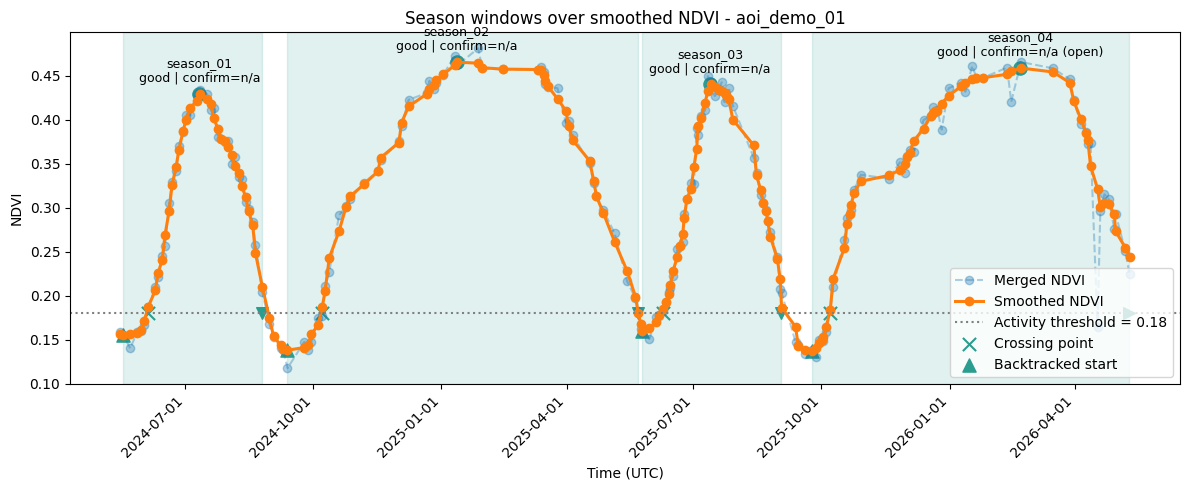

In [12]:
timestamps = [row["timestamp"] for row in usable_rows]
smoothed_values = [row["ndvi_smoothed"] for row in usable_rows]
raw_values = [row["ndvi_raw"] for row in usable_rows]

season_colors = {
    "good": "#2a9d8f",
    "interrupted": "#e76f51",
    "weak": "#e9c46a",
}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(timestamps, raw_values, linestyle="--", alpha=0.35, marker="o", label="Merged NDVI")
ax.plot(timestamps, smoothed_values, linewidth=2.2, marker="o", label="Smoothed NDVI")
ax.axhline(activity_threshold, color="gray", linestyle=":", linewidth=1.5, label=f"Activity threshold = {activity_threshold:.2f}")

for season in season_payload["seasons"]:
    crossing = datetime.fromisoformat(season["crossing_date"])
    start = datetime.fromisoformat(season["start_date"])
    peak = datetime.fromisoformat(season["peak_date"])
    end = datetime.fromisoformat(season["end_date"])
    color = season_colors.get(season["quality_label"], "#8d99ae")

    ax.axvspan(start, end, color=color, alpha=0.14)
    start_value = next(row["ndvi_smoothed"] for row in usable_rows if row["timestamp"].date().isoformat() == season["start_date"])
    crossing_value = next(row["ndvi_smoothed"] for row in usable_rows if row["timestamp"].date().isoformat() == season["crossing_date"])
    ax.scatter([crossing], [activity_threshold], color=color, marker="x", s=90, label="Crossing point" if season is season_payload["seasons"][0] else None)
    ax.scatter([start], [start_value], color=color, marker="^", s=90, label="Backtracked start" if season is season_payload["seasons"][0] else None)
    ax.scatter([peak], [season["peak_ndvi"]], color=color, marker="o", s=90)
    end_marker = ">" if season["is_open"] else "v"
    ax.scatter([end], [activity_threshold], color=color, marker=end_marker, s=70, label="Open end" if season["is_open"] and season is season_payload["seasons"][0] else None)
    ax.text(
        peak,
        season["peak_ndvi"] + 0.01,
        f"{season['season_id']}\n{season['quality_label']} | confirm={season.get('confirmation_level', 'n/a')}{' (open)' if season['is_open'] else ''}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title(f"Season windows over smoothed NDVI - {season_payload['aoi_id']}")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("NDVI")
ax.legend(loc="best")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [13]:
[
    {
        "season_id": season["season_id"],
        "quality_label": season["quality_label"],
        "duration_days": season["duration_days"],
        "peak_ndvi": season["peak_ndvi"],
        "is_open": season["is_open"],
        "confirmation_level": season.get("confirmation_level", "n/a"),
        "season_confidence_note": season["season_confidence_note"],
        "evidence_summary": season["evidence_summary"],
    }
    for season in season_payload["seasons"]
]


[{'season_id': 'season_01',
  'quality_label': 'good',
  'duration_days': 100.0,
  'peak_ndvi': 0.429375,
  'is_open': False,
  'confirmation_level': 'n/a',
  'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.',
  'evidence_summary': 'Good season: peak_ndvi=0.429, rise_gain=0.273.'},
 {'season_id': 'season_02',
  'quality_label': 'good',
  'duration_days': 251.99,
  'peak_ndvi': 0.46543,
  'is_open': False,
  'confirmation_level': 'n/a',
  'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.',
  'evidence_summary': 'Good season: peak_ndvi=0.465, rise_gain=0.327.'},
 {'season_id': 'season_03',
  'quality_label': 'good',
  'duration_days': 100.0,
  'peak_ndvi': 0.440226,
  'is_open': False,
  'confirmation_level': 'n/a',
  'season_confidence_note': 'Gap risk is high. Long or frequent gaps may hide season onset, interruption, or peak timing.',
  'evidence